## Access Radar Turquoisecoast Velocity Hourly Averaged Realtime Non QC (Zarr)
This Jupyter notebook demonstrates how to access and plot radar_TurquoiseCoast_velocity_hourly_averaged_realtime_nonqc data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/52f09a23-63a2-4c14-8b3b-1fc7c8167281).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/radar_TurquoiseCoast_velocity_hourly_averaged_realtime_nonqc.ipynb).


In [1]:
dataset_name = "radar_TurquoiseCoast_velocity_hourly_averaged_realtime_nonqc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 52ms
Checked 155 packages in 1ms


✅ Local version 0.3.12 is up to date (remote: 0.3.11)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4000: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 249 ms, sys: 38.1 ms, total: 287 ms
Wall time: 1.39 s


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	TIME = 85677 ;
	I = 60 ;
	J = 59 ;

variables:
	float64 GDOP(TIME, I, J) ;
		GDOP:comment = This angle is used to assess the impact of Geometric Dilution of Precision. If angle >= 150 or <= 30, then QC flag will not be lower than 4 (see abstract). ;
		GDOP:long_name = radar beam intersection angle ;
		GDOP:units = Degrees ;
		GDOP:valid_max = 180.0 ;
		GDOP:valid_min = 0.0 ;
	int32 I(I) ;
		I:long_name = row index (top most value is 1) ;
		I:units = 1 ;
	int32 J(J) ;
		J:long_name = column index (left most value is 1) ;
		J:units = 1 ;
	float64 LATITUDE(I, J) ;
		LATITUDE:axis = Y ;
		LATITUDE:long_name = latitude ;
		LATITUDE:reference_datum = geographical coordinates, WGS84 datum ;
		LATITUDE:standard_name = latitude ;
		LATITUDE:units = degrees_north ;
		LATITUDE:valid_max = 90.0 ;
		LATITUDE:valid_min = -90.0 ;
	float64 LONGITUDE(I, J) ;
		LONGITUDE:axis = X ;
		LONGITUDE:long_name = longitude ;
		LONGITUDE:reference_datum = geographical coordinates, W

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2009-03-27 09:00:00'), Timestamp('2021-12-31 23:00:00.000003072'))

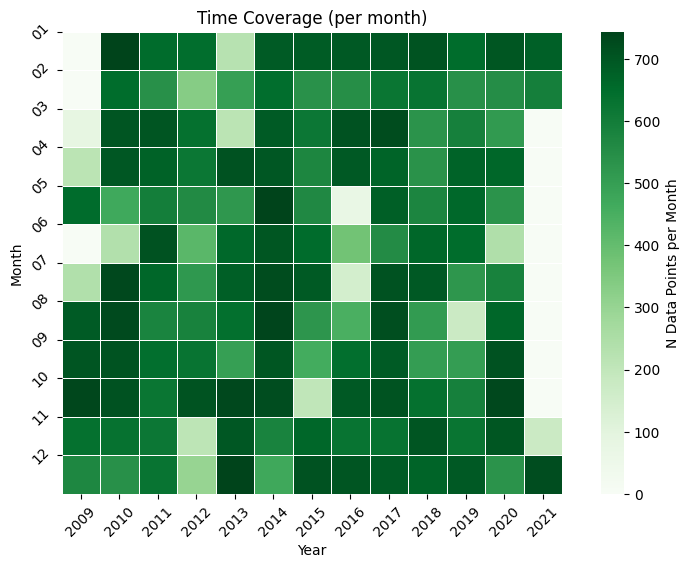

In [7]:
aodn_dataset.plot_time_coverage()

## Plot a gridded variable

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:1144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for the colorbar


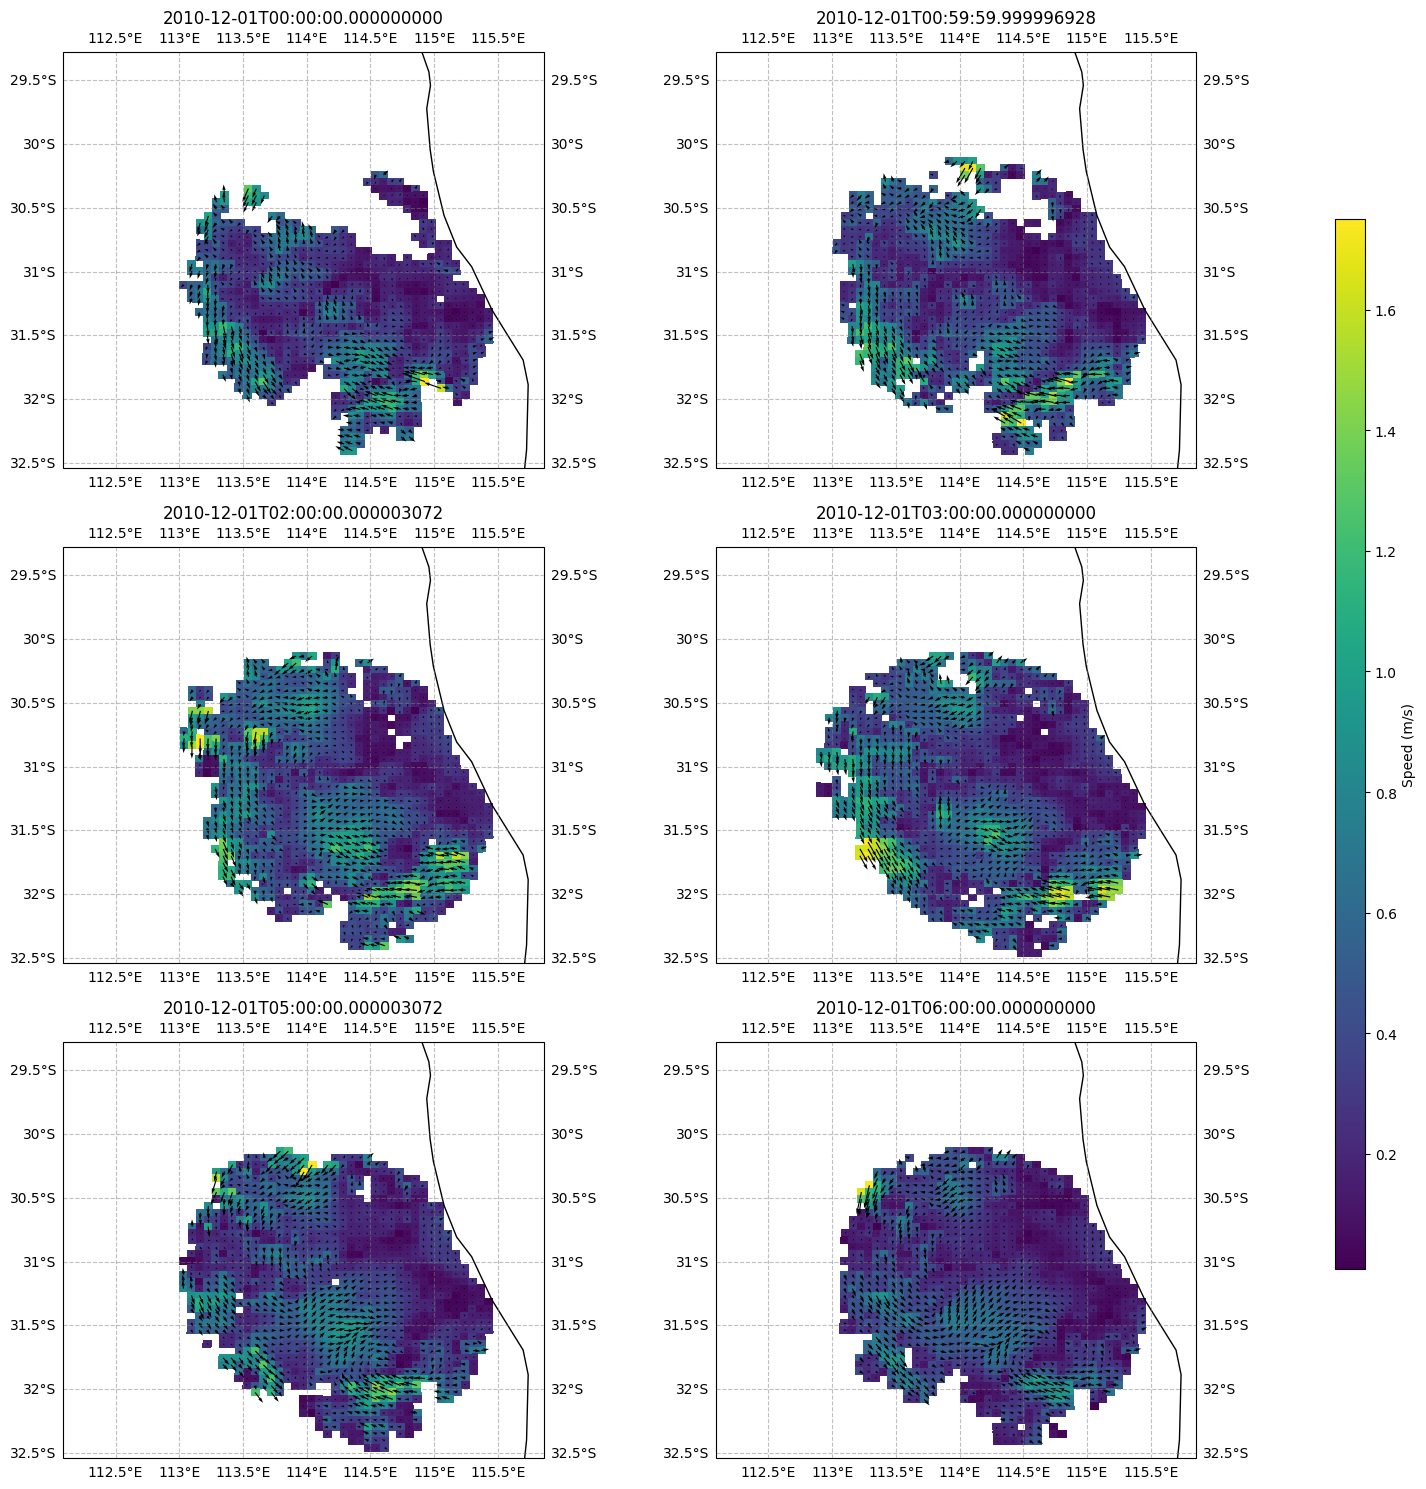

In [8]:
aodn_dataset.plot_radar_water_velocity_gridded(date_start='2010-12-01T00:00:00')

<Figure size 800x800 with 0 Axes>

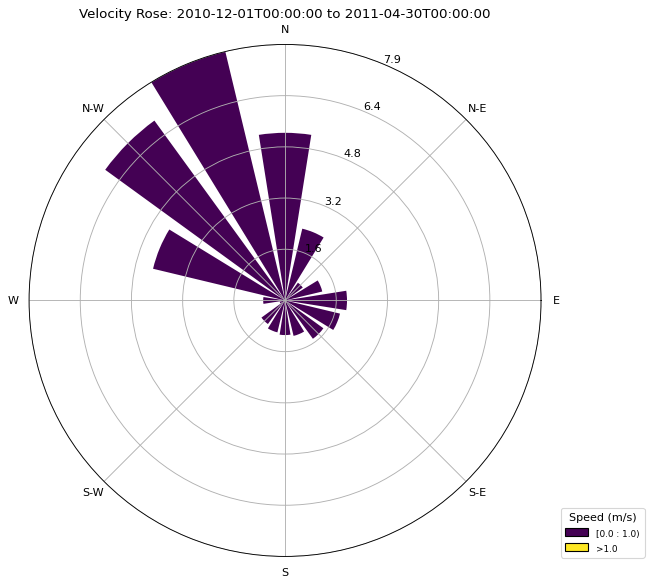

CPU times: user 702 ms, sys: 207 ms, total: 908 ms
Wall time: 3.11 s


In [9]:
%%time
aodn_dataset.plot_radar_water_velocity_rose(date_start='2010-12-01T00:00:00', 
                                            date_end='2011-04-30T00:00:00')

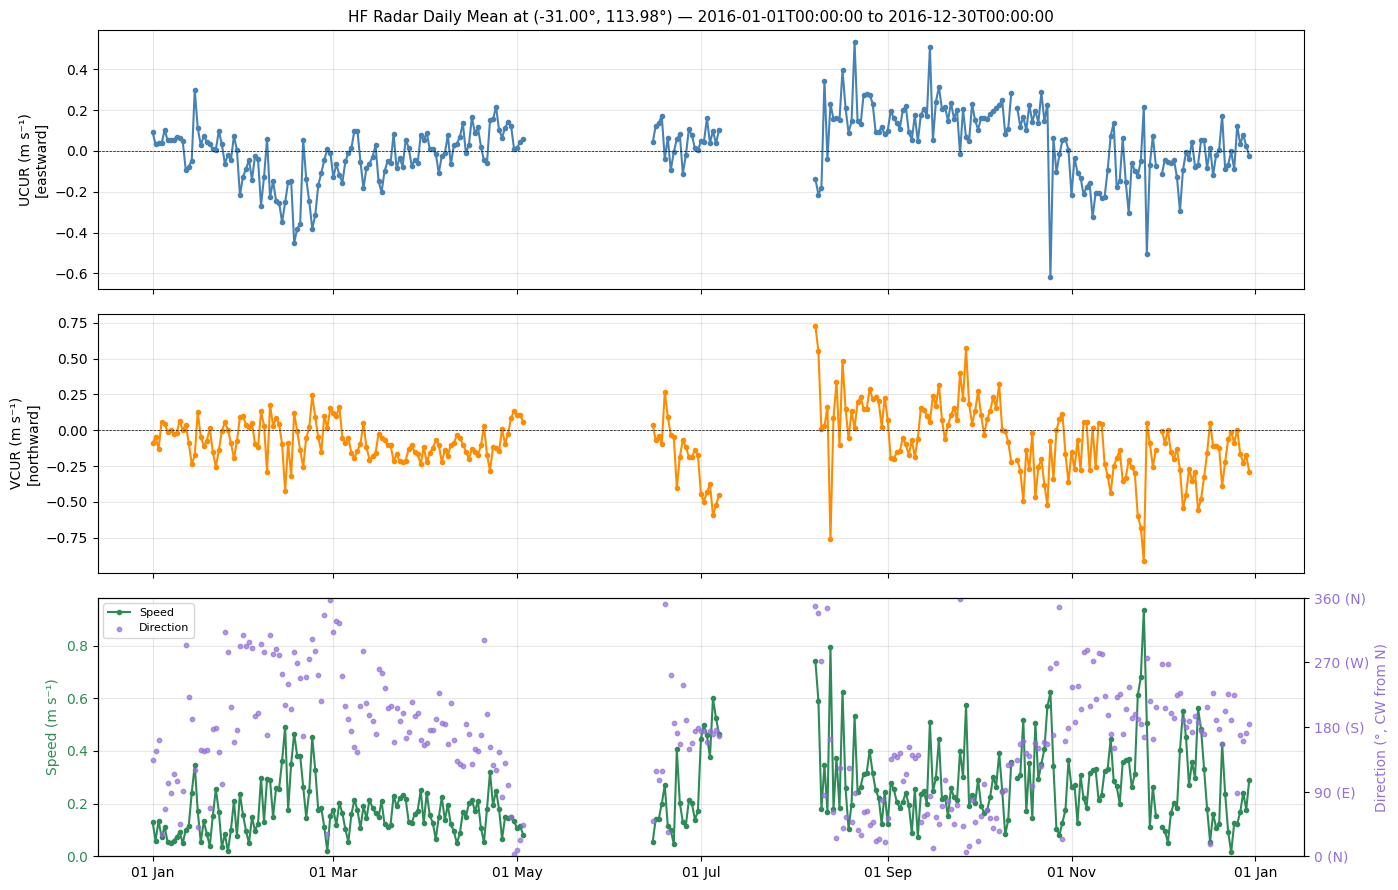

CPU times: user 1.27 s, sys: 441 ms, total: 1.71 s
Wall time: 6.33 s


,u,v,speed,direction
TIME,,,,
2016-01-01,0.093051,-0.092054,0.130891,134.691299
2016-01-02,0.032699,-0.048999,0.058908,146.282954
2016-01-03,0.040683,-0.129290,0.135539,162.533103
2016-01-04,0.037346,0.060896,0.071435,31.519678
2016-01-05,0.103044,0.045439,0.112618,66.203967
...,...,...,...,...
2016-12-26,0.122887,0.005046,0.122991,87.648819
2016-12-27,0.033121,-0.164552,0.167852,168.619464
2016-12-28,0.079742,-0.227534,0.241103,160.686365


In [10]:
%%time
aodn_dataset.plot_radar_water_velocity_timeseries(date_start='2016-01-01T00:00:00', 
                                            date_end='2016-12-30T00:00:00', lat=-31, lon=114)